In [46]:
%load_ext autoreload
%autoreload 2

import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:
import time
import matplotlib
import json

import matplotlib.pyplot as plt
from regex import F
import torch
import sounddevice as sd
from torch.export import Dim

from kokoro import KModel, KPipeline
from kokoro.model import KModelForONNX

import scipy.io.wavfile as wavfile

torch.set_num_threads(8)


In [48]:
MAX_INPUT_LENGTH = 510

config_file = "checkpoints/config.json"
checkpoint_path = "checkpoints/kokoro-v1_0.pth"

kmodel = KModel(config=config_file, model=checkpoint_path, disable_complex=True).to('cpu')
model = KModelForONNX(kmodel).eval()

with open(config_file, 'r', encoding='utf-8') as r:
    config = json.load(r)

timings = {}
dbg=[]

In [49]:
def load_input_ids(pipeline, text):
    if pipeline.lang_code in 'ab':
        _, tokens = pipeline.g2p(text)
        for gs, ps, tks in pipeline.en_tokenize(tokens):
            if not ps:
                continue
    else:
        ps, _ = pipeline.g2p(text)

    if len(ps) > 510:
        ps = ps[:510]

    input_ids = list(filter(lambda i: i is not None, map(lambda p: pipeline.model.vocab.get(p), ps)))
    print(f"text: {text} -> phonemes: {ps} -> input_ids: {input_ids}")
    input_ids = torch.LongTensor([[0, *input_ids, 0]]).to(pipeline.model.device)
    return ps, input_ids

def load_voice(pipeline, voice, phonemes):
    pack = pipeline.load_voice(voice).to('cpu')
    return pack[len(phonemes) - 1]

def load_sample(model):
    pipeline = KPipeline(lang_code='a', model=model.kmodel, device='cpu')
    text = '''
    In today's fast-paced tech world, building software applications has never been easier — thanks to AI-powered coding assistants.'
    '''
    text = '''
    The sky above the port was the color of television, tuned to a dead channel.
    '''

    text = "I had returned to civil practice and had finally abandoned Holmes in his Baker Street rooms, although I continually visited him and occasionally even persuaded him to forgo his Bohemian habits so far as to come and visit us."
    voice = 'checkpoints/voices/af_heart.pt'

    phonemes, input_ids = load_input_ids(pipeline, text)
    style = load_voice(pipeline, voice, phonemes)
    speed = torch.IntTensor([1])

    return input_ids, style, speed

In [50]:


class model_bert(torch.nn.Module):
    def __init__(self, model):
        super(model_bert, self).__init__()
        self.bert = model.bert
        self.bert_encoder = model.bert_encoder

    def forward(self, input_ids, text_mask):
        start = time.perf_counter()
        bert_dur = self.bert(input_ids, attention_mask=text_mask)
        timings['bert'] = time.perf_counter() - start
        
        start = time.perf_counter()
        d_en = self.bert_encoder(bert_dur).transpose(-1, -2)
        timings['bert_encoder'] = time.perf_counter() - start
        
        return d_en

class model_duration_predictor(torch.nn.Module):
    def __init__(self, model):
        super(model_duration_predictor, self).__init__()
        self.predictor = model.predictor
        self.text_encoder = model.text_encoder

    def forward(self, input_ids, d_en, style, text_mask, speed):
        start = time.perf_counter()
        d = self.predictor.text_encoder(d_en, style[:, 128:], text_mask)
        timings['predictor_text_encoder'] = time.perf_counter() - start
        
        start = time.perf_counter()
        x, _ = self.predictor.lstm(d)
        timings['predictor_lstm'] = time.perf_counter() - start

        start = time.perf_counter()
        duration = self.predictor.duration_proj(x)
        duration = text_mask * torch.sigmoid(duration).sum(axis=-1) / speed
        pred_dur = torch.round(duration).squeeze()
        timings['duration_proj'] = time.perf_counter() - start

        input_tensor = d.transpose(-1, -2)
        boundaries = torch.cumsum(pred_dur, dim=0)
        values = torch.arange(boundaries[-1])
        expanded_indices = torch.sum(boundaries.unsqueeze(1) <= values.unsqueeze(0), dim=0)
        
        start = time.perf_counter()
        en = torch.index_select(input_tensor, 2, expanded_indices)
        en, _ = self.predictor.shared(en.transpose(-1, -2))
        timings['predictor_shared'] = time.perf_counter() - start
        
        start = time.perf_counter()
        t_en = self.text_encoder(input_ids, text_mask)
        timings['text_encoder'] = time.perf_counter() - start
        
        asr = torch.index_select(t_en, 2, expanded_indices)

        return pred_dur, input_tensor, expanded_indices, en, asr

In [66]:

from streaming_vocos import StreamingVocos
import torch.nn.functional as F


class VocosDecoder(torch.nn.Module):
    """Vocoder that feeds features directly to StreamingVocos.

    The iSTFTNet encode/decode blocks are NOT used — the vocos vocoder was
    trained on the raw text-encoder ASR output, not on decode-block output.

    Training feature order (642 channels total):
        512  raw asr   (text encoder output, interpolated to T_f0 if needed)
          1  F0_pred   (raw Hz)
          1  N_pred    (raw)
        128  style[:128]
    """

    VOCOS_CKPT = "vocos.pt"
    CHUNK_FRAMES = 16

    def __init__(self, original_decoder=None, chunk_frames: int = CHUNK_FRAMES):
        super().__init__()
        self.vocos = StreamingVocos.from_checkpoint(
            checkpoint_path=self.VOCOS_CKPT,
            chunk_frames=chunk_frames,
            device="cpu",
            use_fp16=False,
        )

    def _build_vocos_features(self, asr, F0_curve, N, s):
        """Build [B, 642, T_f0] matching training format exactly.

        asr      [B, 512, T_asr] — interpolated to T_f0 if shapes differ
        F0_curve [B, T_f0]
        N        [B, T_f0]
        s        [B, 128]
        """
        B, _, T_asr = asr.shape
        T_f0 = F0_curve.shape[-1]

        # Match ASR temporal dim to F0 length (same logic as training dataloader)
        if T_asr != T_f0:
            asr = F.interpolate(asr.float(), size=T_f0, mode="linear", align_corners=False)

        f0    = F0_curve.unsqueeze(1).float()          # [B, 1, T_f0]
        n     = N.unsqueeze(1).float()                 # [B, 1, T_f0]
        s_exp = s.unsqueeze(-1).expand(B, -1, T_f0)   # [B, 128, T_f0]

        return torch.cat([asr, f0, n, s_exp], dim=1)  # [B, 642, T_f0]

    def forward(self, asr, F0_curve, N, s):
        features = self._build_vocos_features(asr, F0_curve, N, s)
        return self.vocos.synthesize(features, is_last=True).squeeze(0)

    def stream_chunks(self, asr, F0_curve, N, s):
        features = self._build_vocos_features(asr, F0_curve, N, s)
        for chunk in self.vocos.stream_chunks(features, is_last=True):
            yield chunk.squeeze(0)

    def reset(self):
        self.vocos.reset()


print("VocosDecoder defined — raw asr → vocos (no iSTFTNet decode blocks)")
print("Feature order: [asr(512), f0_raw(1), noise(1), style(128)] = 642 ch")


VocosDecoder defined — raw asr → vocos (no iSTFTNet decode blocks)
Feature order: [asr(512), f0_raw(1), noise(1), style(128)] = 642 ch


In [61]:

class model_text_encoder(torch.nn.Module):
    def __init__(self, model):
        super(model_text_encoder, self).__init__()
        self.text_encoder = model.text_encoder
        self.predictor = model.predictor
        # Use VocosDecoder: clones encode/decode weights, loads vocos_fp16.pt vocoder
        self.decoder = VocosDecoder(model.decoder)

    def forward(self, en, style, asr):
        start = time.perf_counter()
        F0_pred, N_pred = self.predictor.F0Ntrain(en, style[:, 128:256])
        timings['F0Ntrain'] = time.perf_counter() - start

        start = time.perf_counter()
        audio = self.decoder(asr, F0_pred, N_pred, style[:, 0:128])
        timings['decoder'] = time.perf_counter() - start

        return audio, F0_pred, N_pred

    def stream(self, en, style, asr):
        """Streaming variant — yields audio chunks as they are synthesized."""
        F0_pred, N_pred = self.predictor.F0Ntrain(en, style[:, 128:256])
        yield from self.decoder.stream_chunks(asr, F0_pred, N_pred, style[:, 0:128])


In [62]:
input_ids, style, speed = load_sample(model)


text_mask = torch.zeros(1, MAX_INPUT_LENGTH, dtype=torch.float32).to(input_ids.device)
text_mask[0, :input_ids.shape[1]] = 1
input_ids = torch.nn.functional.pad(input_ids, (0, MAX_INPUT_LENGTH - input_ids.shape[1]))
# text_mask = (input_ids != 0).float()

with torch.no_grad():
    model_bert_instance = model_bert(model.kmodel).eval()
    d_en = model_bert_instance(input_ids, text_mask)

    model_duration_instance = model_duration_predictor(model.kmodel).eval()
    pred_dur, input_tensor, expanded_indices, en, asr = model_duration_instance(input_ids, d_en, style, text_mask, speed)

text: I had returned to civil practice and had finally abandoned Holmes in his Baker Street rooms, although I continually visited him and occasionally even persuaded him to forgo his Bohemian habits so far as to come and visit us. -> phonemes: ˌI hæd ɹətˈɜɹnd tə sˈɪvəl pɹˈæktəs ænd hæd fˈInᵊli əbˈændᵊnd hˈOmz ɪn hɪz bˈAkəɹ stɹˈit ɹˈumz, ɔlðˈO ˌI kəntˈɪnjʊəli vˈɪzɪTᵻd hˌɪm ænd əkˈAʒᵊnəli ˈivən pəɹswˈAdᵻd hˌɪm tə fɔɹɡˈO hɪz bOhˈimiən hˈæbəts sˌO fˈɑɹ æz tə kˈʌm ænd vˈɪzət ˌʌs. -> input_ids: [157, 25, 16, 50, 72, 46, 16, 123, 83, 62, 156, 87, 123, 56, 46, 16, 62, 83, 16, 61, 156, 102, 64, 83, 54, 16, 58, 123, 156, 72, 53, 62, 83, 61, 16, 72, 56, 46, 16, 50, 72, 46, 16, 48, 156, 25, 56, 42, 54, 51, 16, 83, 44, 156, 72, 56, 46, 42, 56, 46, 16, 50, 156, 31, 55, 68, 16, 102, 56, 16, 50, 102, 68, 16, 44, 156, 24, 53, 83, 123, 16, 61, 62, 123, 156, 51, 62, 16, 123, 156, 63, 55, 68, 3, 16, 76, 54, 81, 156, 31, 16, 157, 25, 16, 53, 83, 56, 62, 156, 102, 56, 52, 135, 83, 54, 51, 16, 64, 156, 102, 

In [63]:
model_text_encoder_instance = model_text_encoder(model.kmodel).eval()
audio, F0_pred, N_pred = model_text_encoder_instance(en, style, asr)
print(f"{audio.shape=} {F0_pred.shape=} {N_pred.shape=}")


/rhome/eingerman/Projects/DeepLearning/TTS/Kokoro/.venv/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


audio.shape=torch.Size([325200]) F0_pred.shape=torch.Size([1, 1084]) N_pred.shape=torch.Size([1, 1084])


In [68]:

# --- Full-pass synthesis with VocosDecoder ---
model_text_encoder_instance = model_text_encoder(model.kmodel).eval()

with torch.no_grad():
    audio, F0_pred, N_pred = model_text_encoder_instance(en, style, asr)

print(f"One-shot:  {audio.shape=}  {F0_pred.shape=}  {N_pred.shape=}")
sample_rate = 24000
wavfile.write("output_vocos_oneshot.wav", sample_rate, audio.cpu().numpy())
print("Saved output_vocos_oneshot.wav")

# --- Streaming synthesis (chunk-by-chunk) ---
chunks = []
with torch.no_grad():
    for chunk in model_text_encoder_instance.stream(en, style, asr):
        chunks.append(chunk.cpu())
        print(f"  chunk: {chunk.shape}")

audio_streaming = torch.cat(chunks, dim=-1)
print(f"Streaming: {audio_streaming.shape=}")
wavfile.write("output_vocos_streaming.wav", sample_rate, audio_streaming.numpy())
print("Saved output_vocos_streaming.wav")


One-shot:  audio.shape=torch.Size([325200])  F0_pred.shape=torch.Size([1, 1084])  N_pred.shape=torch.Size([1, 1084])
Saved output_vocos_oneshot.wav
  chunk: torch.Size([4800])
  chunk: torch.Size([4800])
  chunk: torch.Size([4800])
  chunk: torch.Size([4800])
  chunk: torch.Size([4800])
  chunk: torch.Size([4800])
  chunk: torch.Size([4800])
  chunk: torch.Size([4800])
  chunk: torch.Size([4800])
  chunk: torch.Size([4800])
  chunk: torch.Size([4800])
  chunk: torch.Size([4800])
  chunk: torch.Size([4800])
  chunk: torch.Size([4800])
  chunk: torch.Size([4800])
  chunk: torch.Size([4800])
  chunk: torch.Size([4800])
  chunk: torch.Size([4800])
  chunk: torch.Size([4800])
  chunk: torch.Size([4800])
  chunk: torch.Size([4800])
  chunk: torch.Size([4800])
  chunk: torch.Size([4800])
  chunk: torch.Size([4800])
  chunk: torch.Size([4800])
  chunk: torch.Size([4800])
  chunk: torch.Size([4800])
  chunk: torch.Size([4800])
  chunk: torch.Size([4800])
  chunk: torch.Size([4800])
  chunk: tor

In [69]:

from IPython.display import display, Audio, HTML

display(HTML("<b>Full synthesis (one-shot VocosDecoder):</b>"))
display(Audio(audio.cpu().numpy(), rate=sample_rate))

display(HTML("<b>Streaming synthesis (chunked VocosDecoder):</b>"))
display(Audio(audio_streaming.cpu().numpy(), rate=sample_rate))

# Side-by-side difference metric
diff = (audio.cpu() - audio_streaming.cpu()).abs().max().item()
print(f"Max sample diff between one-shot and streaming: {diff:.6f}")


Max sample diff between one-shot and streaming: 0.000000


/rhome/eingerman/Projects/DeepLearning/TTS/Kokoro/.venv/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Reference : rms=0.0520  max=0.6489
Vocos     : rms=0.0538  max=0.7265


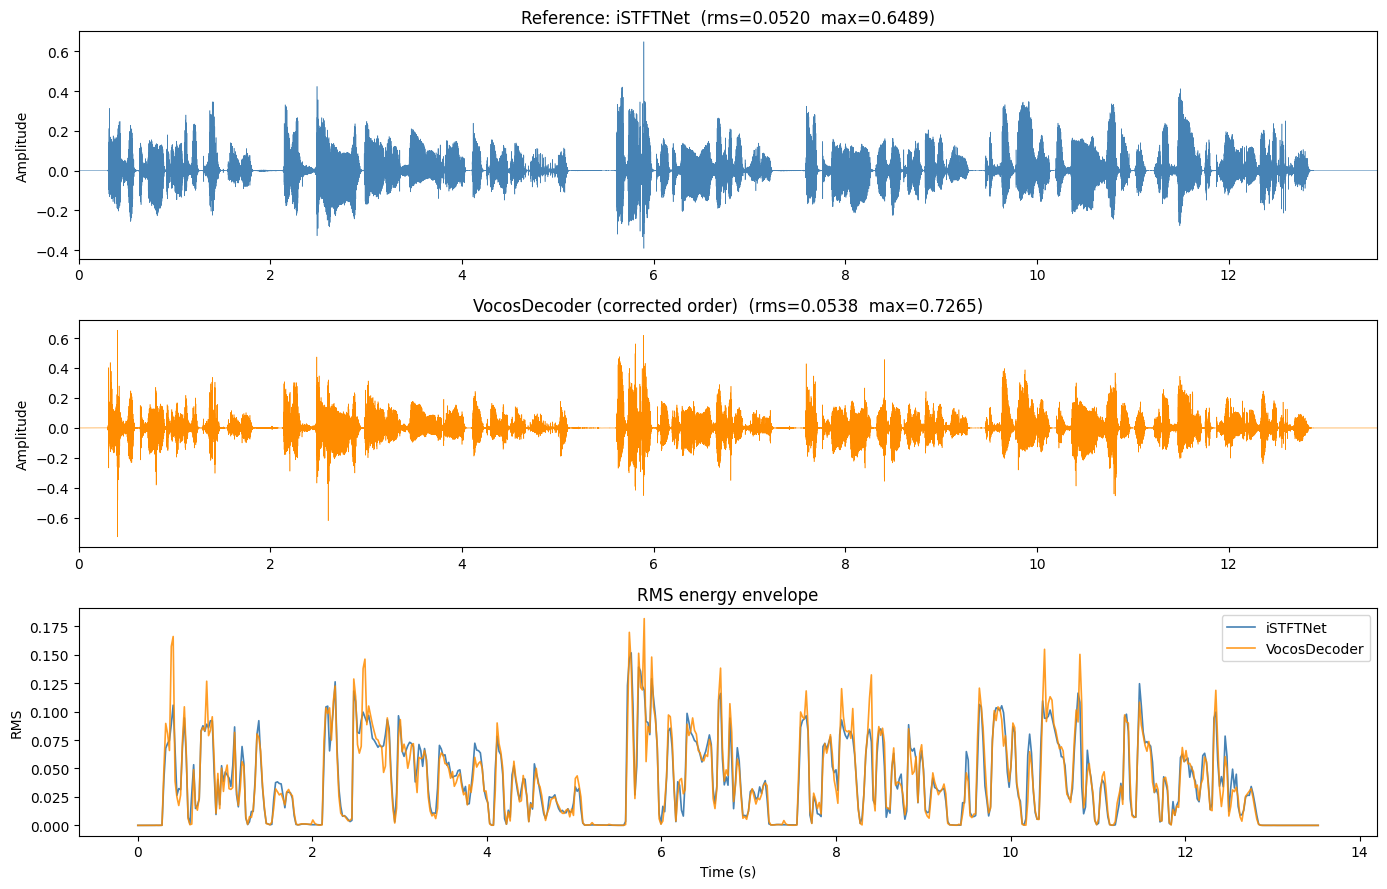

In [73]:

# ── Plot & audio: iSTFTNet reference vs corrected VocosDecoder ─────────────────

from IPython.display import display, Audio, HTML

# Re-instantiate with the corrected VocosDecoder
model_text_encoder_instance = model_text_encoder(model.kmodel).eval()

with torch.no_grad():
    audio_ref   = model.kmodel.decoder(asr, F0_pred, N_pred, style[:, 0:128]).squeeze().detach().cpu()
    audio_vocos = model_text_encoder_instance.decoder(asr, F0_pred, N_pred, style[:, 0:128]).detach().cpu()

print(f"Reference : rms={audio_ref.pow(2).mean().sqrt():.4f}  max={audio_ref.abs().max():.4f}")
print(f"Vocos     : rms={audio_vocos.pow(2).mean().sqrt():.4f}  max={audio_vocos.abs().max():.4f}")

def plot_wave(ax, wav, title, color):
    t = torch.arange(len(wav)).float() / sample_rate
    ax.plot(t.numpy(), wav.detach().float().numpy(), linewidth=0.4, color=color)
    rms = float(wav.pow(2).mean().sqrt())
    ax.set_title(f"{title}  (rms={rms:.4f}  max={float(wav.abs().max()):.4f})")
    ax.set_ylabel("Amplitude")
    ax.set_xlim(0, t[-1].item())

hop = 512
def rms_env(wav):
    return [wav[i:i+hop].pow(2).mean().sqrt().item() for i in range(0, len(wav)-hop, hop)]

t_env_ref   = torch.arange(len(rms_env(audio_ref)))   * hop / sample_rate
t_env_vocos = torch.arange(len(rms_env(audio_vocos))) * hop / sample_rate

fig, axes = plt.subplots(3, 1, figsize=(14, 9))
plot_wave(axes[0], audio_ref,   "Reference: iSTFTNet",           "steelblue")
plot_wave(axes[1], audio_vocos, "VocosDecoder (corrected order)", "darkorange")
axes[2].plot(t_env_ref.numpy(),   rms_env(audio_ref),   label="iSTFTNet",    color="steelblue",   linewidth=1.2)
axes[2].plot(t_env_vocos.numpy(), rms_env(audio_vocos), label="VocosDecoder",color="darkorange",  linewidth=1.2, alpha=0.85)
axes[2].set_title("RMS energy envelope")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("RMS")
axes[2].legend()
plt.tight_layout()
plt.savefig("vocos_comparison_fixed.png", dpi=110)
plt.show()

display(HTML("<b>Reference (iSTFTNet):</b>"))
display(Audio(audio_ref.numpy(), rate=sample_rate))
display(HTML("<b>VocosDecoder (corrected channel order + raw F0):</b>"))
display(Audio(audio_vocos.numpy(), rate=sample_rate))
